<a href="https://colab.research.google.com/github/2420030483-code/WEEK-DS/blob/main/week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Min-Max Normalization
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00

Z Score Standardization
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214

One Hot Encoding
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False

PCA Variance Ratio
[0.72627656 0.1730423 ]


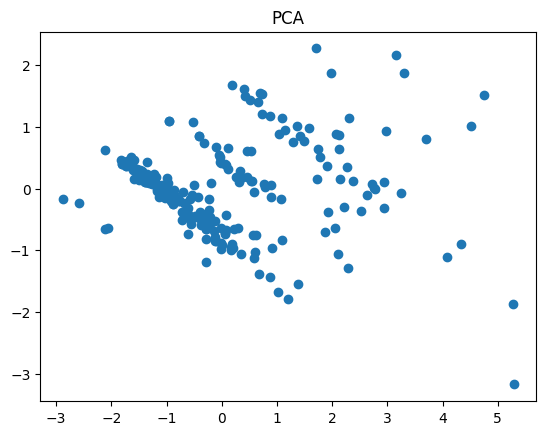

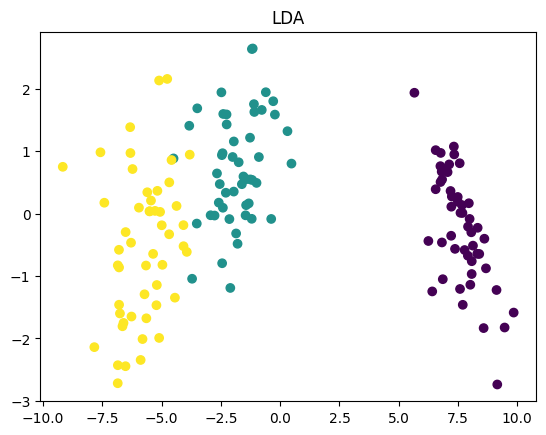

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris

# ---------------------------
# NORMALIZATION
# ---------------------------

data = pd.DataFrame({
    'A':[10,20,30,40,50],
    'B':[5,15,25,35,45]
})

scaler = MinMaxScaler()

normalized = scaler.fit_transform(data)

print("Min-Max Normalization")
print(pd.DataFrame(normalized,columns=data.columns))

# ---------------------------
# STANDARDIZATION
# ---------------------------

std_scaler = StandardScaler()

standardized = std_scaler.fit_transform(data)

print("\nZ Score Standardization")
print(pd.DataFrame(standardized,columns=data.columns))

# ---------------------------
# ONE HOT ENCODING
# ---------------------------

df = pd.DataFrame({
    'Color':['Red','Blue','Green','Red','Blue']
})

encoded = pd.get_dummies(df)

print("\nOne Hot Encoding")
print(encoded)

# ---------------------------
# PCA
# ---------------------------

tips = sns.load_dataset("tips")

numeric = tips.select_dtypes(include=['int64','float64'])

scaled = StandardScaler().fit_transform(numeric)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled)

print("\nPCA Variance Ratio")
print(pca.explained_variance_ratio_)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1','PC2']
)

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2']
)

plt.title("PCA")
plt.show()

# ---------------------------
# LDA
# ---------------------------

iris = load_iris()

X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X,y)

plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=y
)

plt.title("LDA")
plt.show()